In [9]:
# Імпорт бібліотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Завантаження CSV-файлу
df = pd.read_csv("dataset_house_apartment.csv")

# Перегляд перших рядків
df.head()


,locality,type_of_property,subtype_of_property,price,type_of_sale,number_of_rooms,house_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,surface_of_the_plot_of_land,number_of_facades,swimming_pool,state_of_the_building,construction_year
0,1050,house,house,340000,for sale,6.0,203.0,1,NaN,0,1,NaN,0,NaN,95.0,NaN,2.0,0,to be done up,1901.0
1,1880,house,villa,525000,for sale,6.0,250.0,1,NaN,0,1,40.0,1,430.0,826.0,NaN,4.0,0,as new,1992.0
2,4900,house,exceptional property,550000,for sale,11.0,475.0,1,NaN,0,1,NaN,1,1400.0,1543.0,NaN,4.0,0,good,1853.0
3,7912,house,villa,550000,for sale,4.0,325.0,1,NaN,0,1,125.0,1,2333.0,3570.0,NaN,4.0,0,good,1918.0
4,6032,house,house,550000,for sale,5.0,400.0,1,NaN,0,1,80.0,1,500.0,616.0,NaN,3.0,0,as new,1977.0


In [10]:
# Перевірка типів даних
df.dtypes

# Перевірка кількості пропущених значень
df.isna().sum()

locality                           0
type_of_property                   0
subtype_of_property                0
price                              0
type_of_sale                       0
number_of_rooms                    2
house_area                      8632
fully_equipped_kitchen             0
furnished                      52077
open_fire                          0
terrace                            0
terrace_area                   34559
garden                             0
garden_area                    43624
surface_of_the_land            22724
surface_of_the_plot_of_land    52077
number_of_facades              13650
swimming_pool                      0
state_of_the_building          13586
construction_year              21369
dtype: int64

In [11]:
# Приведення важливих колонок до числового типу (ціна, площа, рік побудови)
cols_to_numeric = ["price", "house_area", "construction_year"]

for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Перевірка кількості пропущених значень після перетворення
df[cols_to_numeric].isna().sum()

# Видалення рядків з пропусками у важливих колонках
df_clean = df.dropna(subset=cols_to_numeric)

# Перевірка розміру очищеного датафрейму
df_clean.shape

(26874, 20)

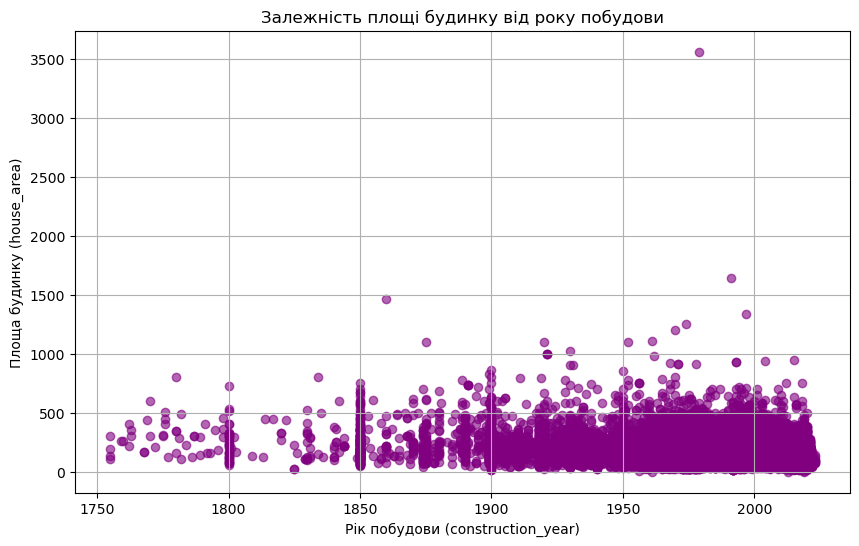

In [12]:
# Завдання 2. Scatter plot: залежність площі від року побудови

# Копія датафрейму для роботи
df_2 = df_clean.copy()

# Побудова scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df_2["construction_year"], df_2["house_area"], color="purple", marker='o', alpha=0.6)
plt.title("Залежність площі будинку від року побудови")
plt.xlabel("Рік побудови (construction_year)")
plt.ylabel("Площа будинку (house_area)")
plt.grid(True)
plt.show()

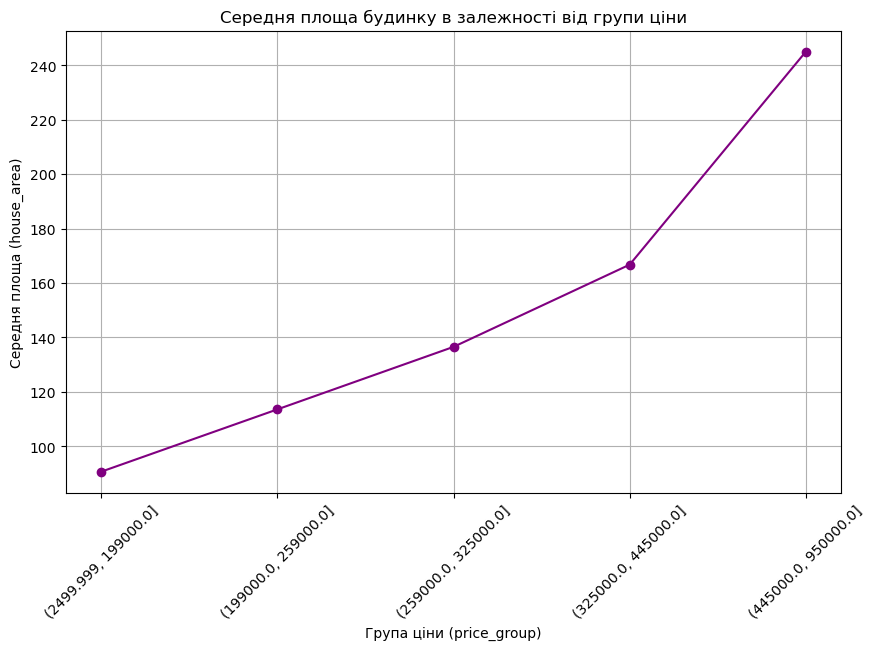

In [13]:
# Завдання 3. Line chart: середня площа по групах ціни

# Копія датафрейму
df_3 = df_clean.copy()

# Створення цінових груп (5 квантилів)
df_3["price_group"] = pd.qcut(df_3["price"], q=5)

# Групування та обчислення середньої площі
avg_area = df_3.groupby("price_group")["house_area"].mean()

# Побудова графіка
plt.figure(figsize=(10, 6))
plt.plot(avg_area.index.astype(str), avg_area.values, marker='o', color='purple')
plt.title("Середня площа будинку в залежності від групи ціни")
plt.xlabel("Група ціни (price_group)")
plt.ylabel("Середня площа (house_area)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

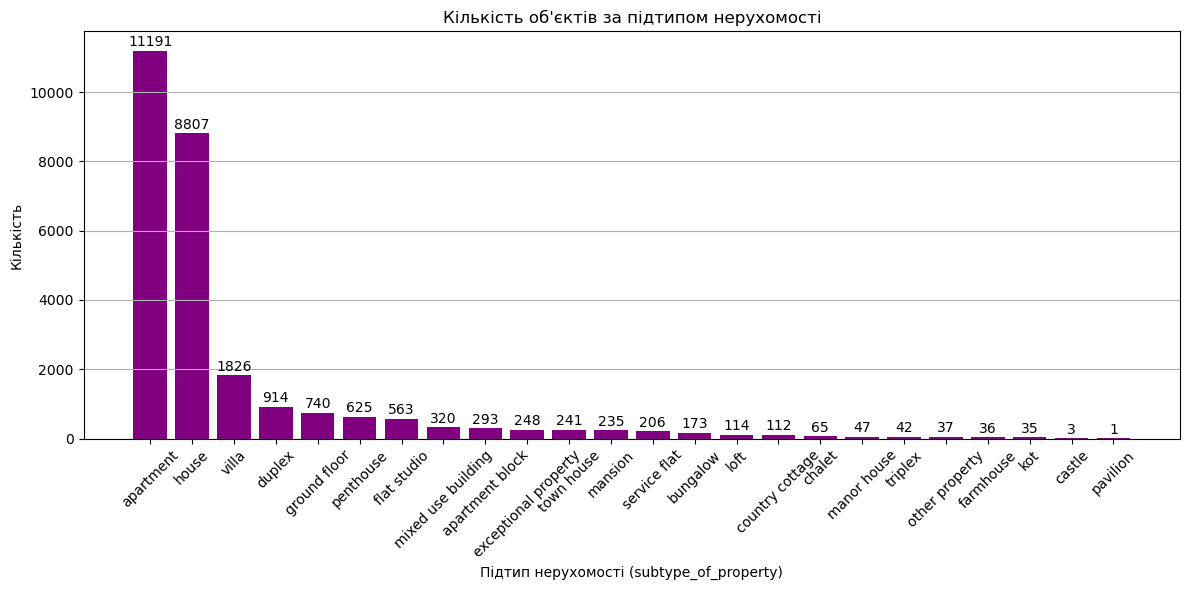

In [14]:
# Завдання 4: Bar chart по subtype_of_property

# Розрахунок кількості об'єктів
subtype_counts = df_clean["subtype_of_property"].value_counts()

# Побудова графіка
plt.figure(figsize=(12, 6))
bars = plt.bar(subtype_counts.index, subtype_counts.values, color='purple')

# Додамо підписи над кожним стовпчиком
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom')

plt.title("Кількість об'єктів за підтипом нерухомості")
plt.xlabel("Підтип нерухомості (subtype_of_property)")
plt.ylabel("Кількість")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [18]:
## Завдання 5 — Lineplot у Seaborn, який показує зміну середньої площі area за групами ціни.
# Копія датафрейму
df_5 = df_clean.copy()

# Створення груп цін (5 квантилів)
df_5["price_group"] = pd.qcut(df_5["price"], q=5)

# Агрегована таблиця: середня площа по групах цін
grouped = df_5.groupby("price_group", observed=True)["house_area"].mean().reset_index()
# Перегляд перших рядків
df.head()

,locality,type_of_property,subtype_of_property,price,type_of_sale,number_of_rooms,house_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,surface_of_the_plot_of_land,number_of_facades,swimming_pool,state_of_the_building,construction_year
0,1050,house,house,340000.0,for sale,6.0,203.0,1,NaN,0,1,NaN,0,NaN,95.0,NaN,2.0,0,to be done up,1901.0
1,1880,house,villa,525000.0,for sale,6.0,250.0,1,NaN,0,1,40.0,1,430.0,826.0,NaN,4.0,0,as new,1992.0
2,4900,house,exceptional property,550000.0,for sale,11.0,475.0,1,NaN,0,1,NaN,1,1400.0,1543.0,NaN,4.0,0,good,1853.0
3,7912,house,villa,550000.0,for sale,4.0,325.0,1,NaN,0,1,125.0,1,2333.0,3570.0,NaN,4.0,0,good,1918.0
4,6032,house,house,550000.0,for sale,5.0,400.0,1,NaN,0,1,80.0,1,500.0,616.0,NaN,3.0,0,as new,1977.0


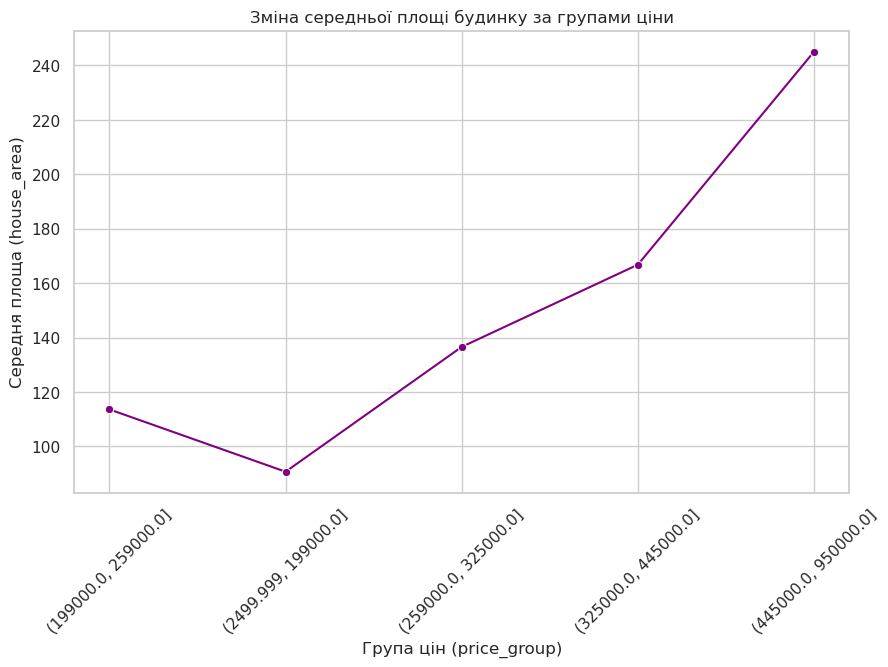

In [21]:
# Копія датафрейму
df_5 = df_clean.copy()

# Створення груп цін (5 квантилів) + перетворення в рядки
df_5["price_group"] = pd.qcut(df_5["price"], q=5).astype(str)

# Агрегована таблиця: середня площа по групах цін
grouped = df_5.groupby("price_group", observed=True)["house_area"].mean().reset_index()

# Побудова графіка
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped, x="price_group", y="house_area", marker='o', color='purple')

plt.title("Зміна середньої площі будинку за групами ціни")
plt.xlabel("Група цін (price_group)")
plt.ylabel("Середня площа (house_area)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

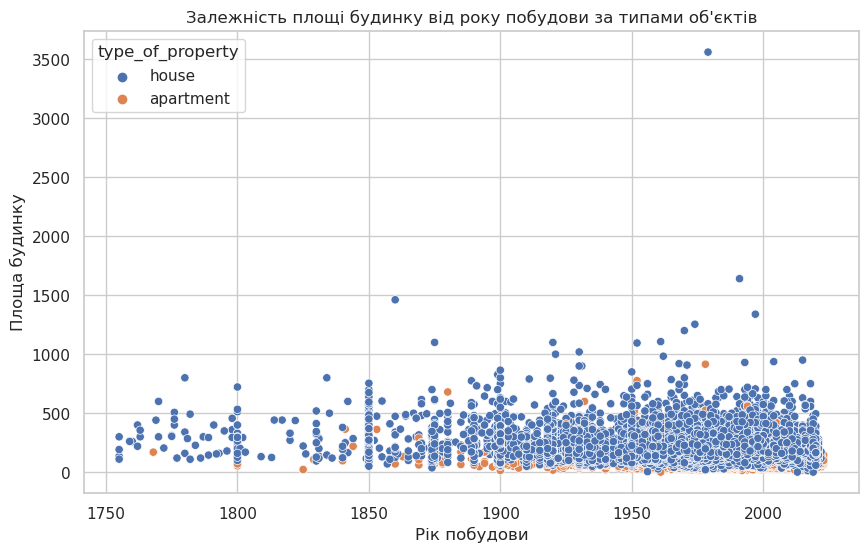

In [27]:
##Завдання 6. Побудова scatterplot у Seaborn, де:X - construction_year; Y - house_area;hue - type_of_property (тип обʼєкту). 
# Копія датафрейму
df_6 = df_clean.copy()
# Побудова графіка
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='construction_year', y='house_area', hue='type_of_property')
plt.title("Залежність площі будинку від року побудови за типами об'єктів")
plt.xlabel("Рік побудови")
plt.ylabel("Площа будинку")
plt.grid(True)
plt.show()

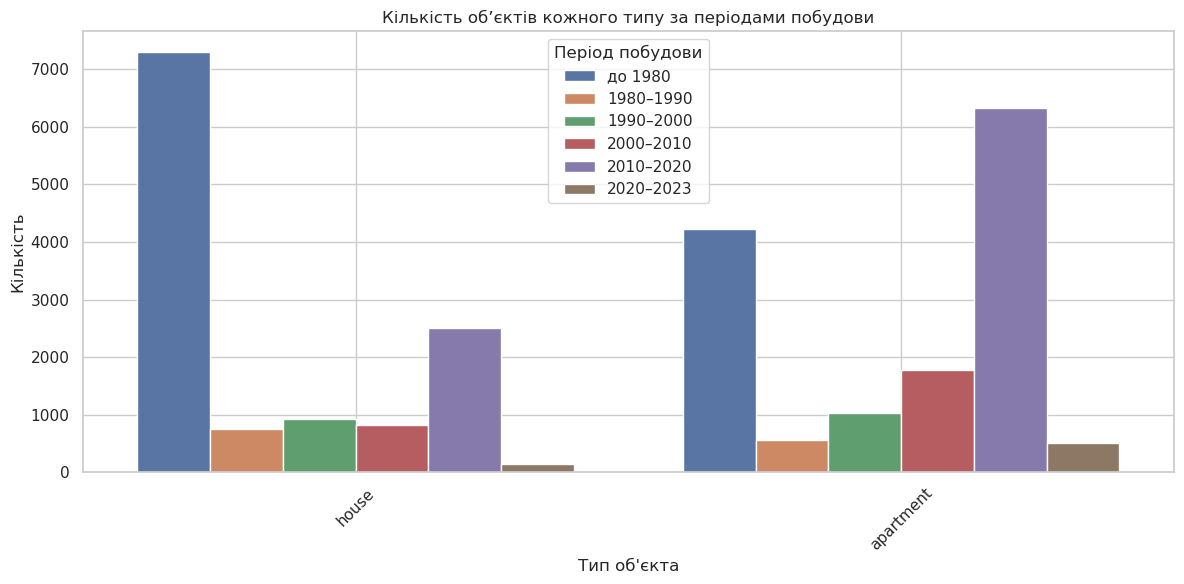

In [29]:
##Завдання 7.Побудова countplot у Seaborn для type, з hue - construction_year
# Копія датафрейму
df_temp = df_clean.copy()

# Створення категорій побудови
bins = [0, 1980, 1990, 2000, 2010, 2020, 2023]
labels = ['до 1980', '1980–1990', '1990–2000', '2000–2010', '2010–2020', '2020–2023']
df_temp['construction_period'] = pd.cut(df_temp['construction_year'], bins=bins, labels=labels)
plt.figure(figsize=(12, 6))
sns.countplot(data=df_temp, x='type_of_property', hue='construction_period')
plt.title("Кількість обʼєктів кожного типу за періодами побудови")
plt.xlabel("Тип об'єкта")
plt.ylabel("Кількість")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Період побудови')
plt.tight_layout()
plt.show()


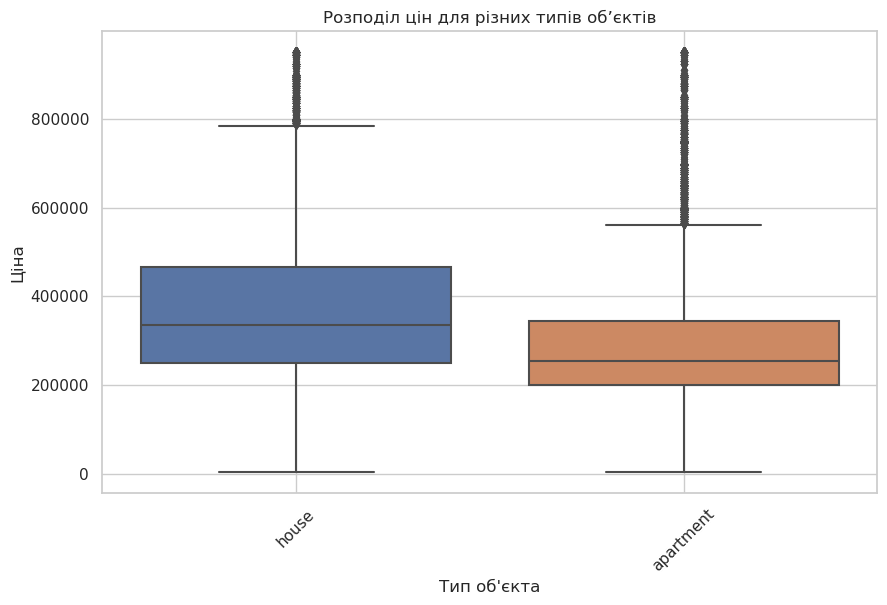

In [24]:
## Завдання 8.Побудова boxplot, який показує розподіл price для різних type_of_property.
# Копія датафрейму
df_8 = df_clean.copy()
#Побудова графіка
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='type_of_property', y='price')
plt.title("Розподіл цін для різних типів обʼєктів")
plt.xlabel("Тип об'єкта")
plt.ylabel("Ціна")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

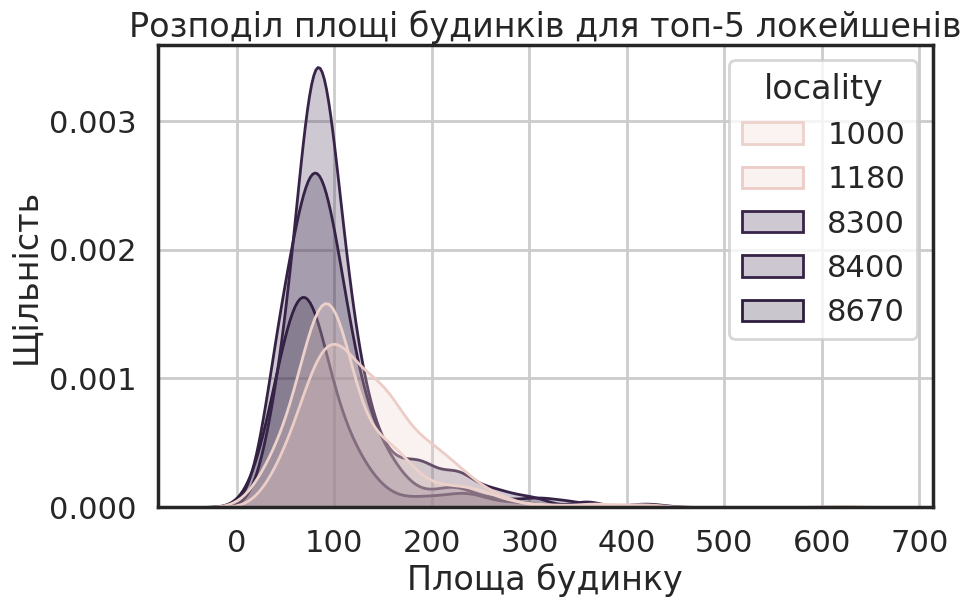

In [34]:
## Завдання 9. Побудуй kdeplot, що відображає розподіл house_area, поділений за топ5 locality.
# Копія датафрейму
df_9 = df_clean.copy()
# Топ-5 локейшенів
top5_locality = df_clean['locality'].value_counts().nlargest(5).index
df_top5 = df_clean[df_clean['locality'].isin(top5_locality)]
#Побудова графіка
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_top5, x='house_area', hue='locality', fill=True)
plt.title("Розподіл площі будинків для топ-5 локейшенів")
plt.xlabel("Площа будинку")
plt.ylabel("Щільність")
plt.grid(True)
plt.show()

### Завдання 10: Налаштування стилю (`set_style`) та контексту (`set_context`) у Seaborn

Бібліотека **Seaborn** дозволяє налаштовувати вигляд графіків за допомогою функцій:

#### 🎨 `set_style()` — візуальний стиль графіка
- `"white"` — мінімалістичний білий фон (добре підходить для презентацій)
- `"whitegrid"` — білий фон із сіткою (зручно для аналітики)
- `"dark"`, `"darkgrid"`, `"ticks"` — альтернативні варіанти з темнішим фоном або шкалою

#### 📐 `set_context()` — масштаб елементів (тексту, міток, тощо)
- `"notebook"` — стандарт для роботи в ноутбуці
- `"talk"` — більші шрифти, ідеально для обговорення
- `"poster"` — великий масштаб для слайдів презентацій
- `"paper"` — для наукових публікацій

#### ✅ Рекомендації:
- **Для перегляду в ноутбуці**:
  ```python
  sns.set_style("whitegrid")
  sns.set_context("notebook")
  ```
- **Для презентації**:
  ```python
  sns.set_style("white")
  sns.set_context("poster")
  ```


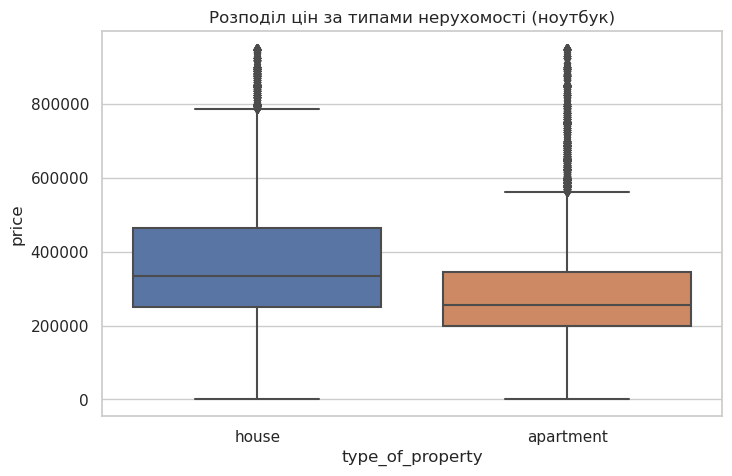

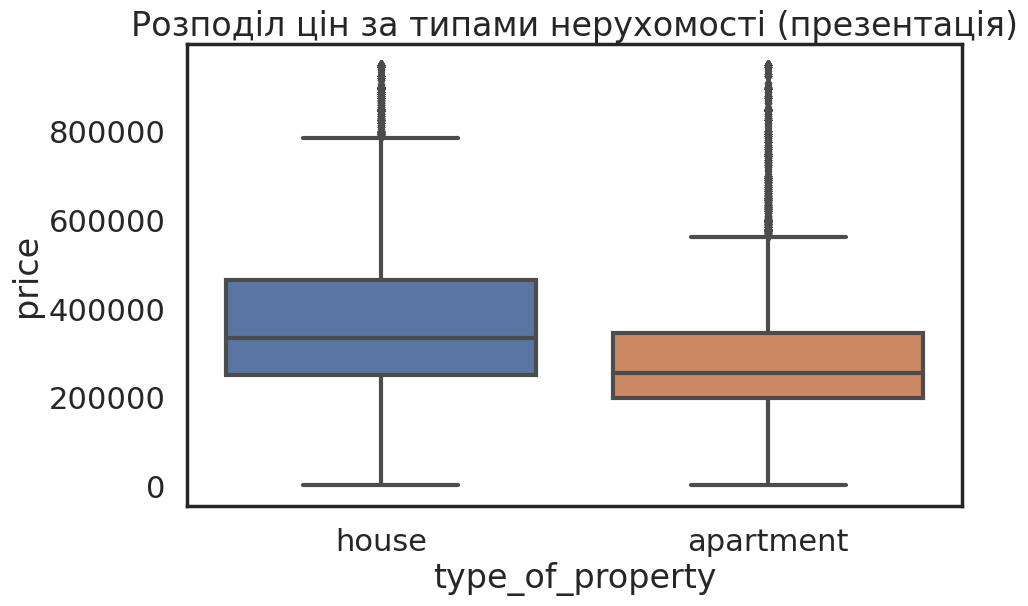

In [33]:
# Варіант 1: Стиль для ноутбуку
sns.set_style("whitegrid")
sns.set_context("notebook")

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="type_of_property", y="price")
plt.title("Розподіл цін за типами нерухомості (ноутбук)")
plt.show()

# Варіант 2: Стиль для презентації
sns.set_style("white")
sns.set_context("poster")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x="type_of_property", y="price")
plt.title("Розподіл цін за типами нерухомості (презентація)")
plt.show()
